# **Pavan S - 24BAD085**

---

## Uploading the Dataset

In [13]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (1).csv


## Loading the Dataset

In [14]:
import pandas as pd

raw_df = pd.read_csv('spam.csv', encoding='latin-1')

label_col = raw_df.columns[0]

text_cols = raw_df.columns[1:]

raw_df['message'] = raw_df[text_cols].astype(str).apply(
    lambda row: ' '.join([x for x in row if x != 'nan']),
    axis=1
)

df = raw_df[[label_col, 'message']]
df.columns = ['label', 'message']

print(df.shape)
df.head()

(5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Validate Data

In [15]:
print(df['label'].value_counts())
print(df['message'].str.len().describe())

label
ham     4825
spam     747
Name: count, dtype: int64
count    5572.000000
mean       80.692211
std        60.007878
min         2.000000
25%        36.000000
50%        62.000000
75%       123.000000
max       910.000000
Name: message, dtype: float64


## Clean Text

In [16]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_msg'] = df['message'].apply(clean_text)

df[['message','clean_msg']].head()

/tmp/ipython-input-3849243724.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_msg'] = df['message'].apply(clean_text)


,message,clean_msg
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...


## Encoding Labels

In [17]:
df['label'] = df['label'].map({'ham':0, 'spam':1})
df['label'].value_counts()

/tmp/ipython-input-912047665.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['label'].map({'ham':0, 'spam':1})


,count
label,
0,4825
1,747


##  Converting Text to Numerical Features

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=2)
X = vectorizer.fit_transform(df['clean_msg'])
y = df['label']

print(X.shape)

(5572, 4210)


## Train‑Test Split




In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Multinomial Naïve Bayes

In [20]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

MultinomialNB()

## Evaluate Model

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9748878923766816
Precision: 1.0
Recall   : 0.8133333333333334
F1 Score : 0.8970588235294118


## Confusion Matrix

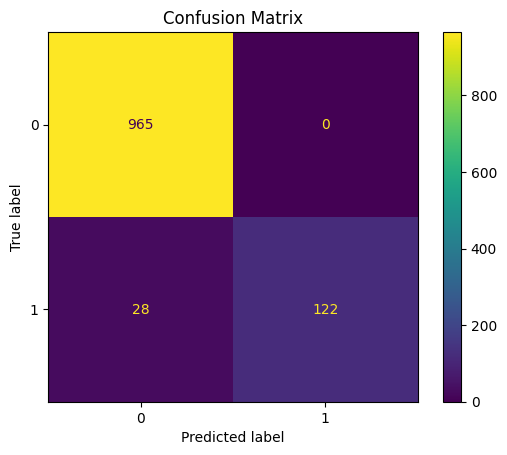

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

## Top Words Influencing Spam Classification

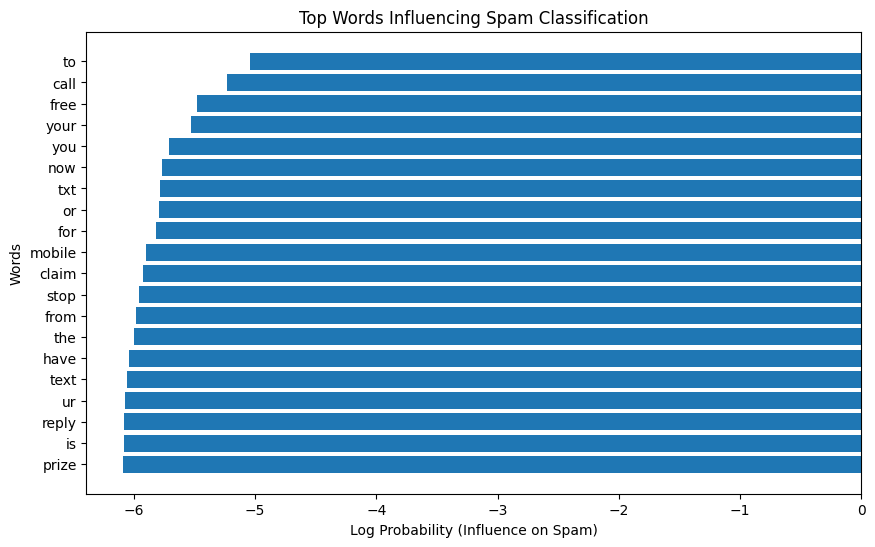

In [23]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = vectorizer.get_feature_names_out()
spam_log_probs = model.feature_log_prob_[1]

top_indices = np.argsort(spam_log_probs)[-20:]
top_words = feature_names[top_indices]
top_scores = spam_log_probs[top_indices]

plt.figure(figsize=(10,6))
plt.barh(top_words, top_scores)
plt.xlabel("Log Probability (Influence on Spam)")
plt.ylabel("Words")
plt.title("Top Words Influencing Spam Classification")
plt.show()

## Word frequency comparison (Spam vs Ham)

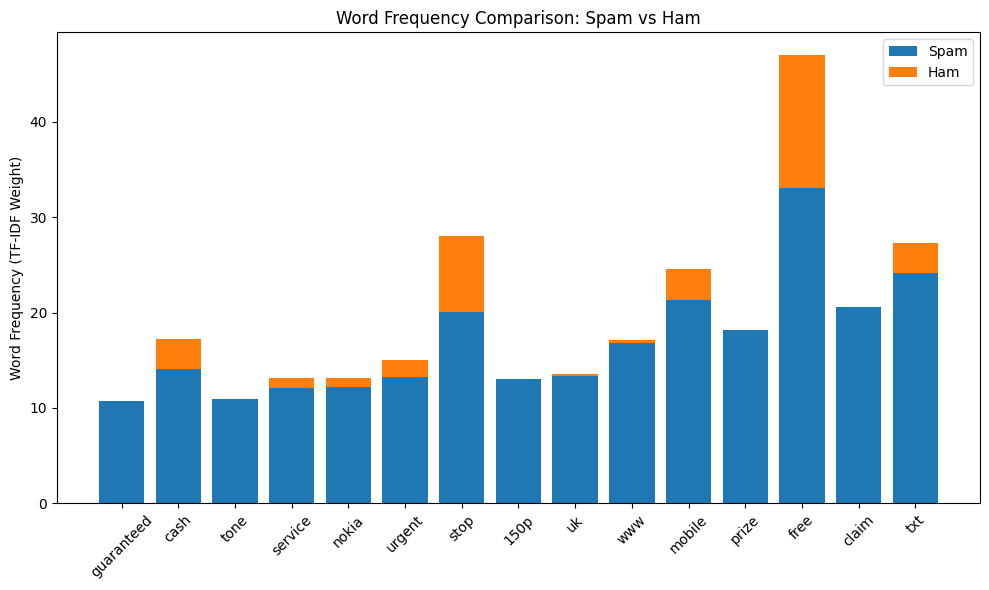

In [24]:
feature_names = vectorizer.get_feature_names_out()

mask_spam = (y == 1).values
mask_ham  = (y == 0).values

spam_sum = X[mask_spam].sum(axis=0).A1
ham_sum  = X[mask_ham].sum(axis=0).A1

diff = spam_sum - ham_sum

top_indices = diff.argsort()[-15:]

words = [feature_names[i] for i in top_indices]
spam_vals = [spam_sum[i] for i in top_indices]
ham_vals  = [ham_sum[i] for i in top_indices]

x = range(len(words))

plt.figure(figsize=(10,6))
plt.bar(x, spam_vals, label="Spam")
plt.bar(x, ham_vals, bottom=spam_vals, label="Ham")

plt.xticks(x, words, rotation=45)
plt.ylabel("Word Frequency (TF-IDF Weight)")
plt.title("Word Frequency Comparison: Spam vs Ham")
plt.legend()
plt.tight_layout()
plt.show()